
Menarik data jalanan Surabaya dari OSRM...
Memulai optimasi Simulated Annealing...

Drawing dynamic colored road segments...


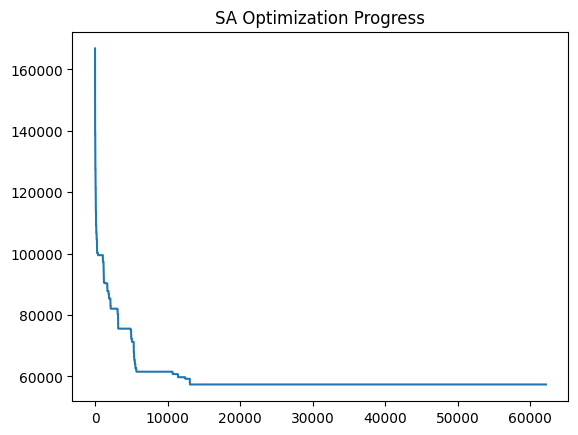


[SUKSES] Rute SA sudah siap di 'rute_sepeda_surabaya.html'!


In [5]:
import requests
import folium
from folium import plugins
import random
import os
import matplotlib.pyplot as plt
import numpy as np
import scipy.spatial as spatial
import math

# ==========================================
# 1. DATASET 25 LOKASI + ELEVASI (STATED)
# ==========================================
locations = {
   "1. Monumen Kapal Selam": {"coord": (-7.2654, 112.7503), "elev": 4.0},
    "2. Tugu Pahlawan": {"coord": (-7.2453, 112.7379), "elev": 9.0},
    "3. Jembatan Merah": {"coord": (-7.2365, 112.7383), "elev": 6.0},
    "4. Hotel Majapahit": {"coord": (-7.2573, 112.7388), "elev": 9.0},
    "5. Balai Kota Surabaya": {"coord": (-7.2589, 112.7469), "elev": 6.0},
    "6. House of Sampoerna": {"coord": (-7.2306, 112.7343), "elev": 6.0},
    "7. Museum Surabaya (Siola)": {"coord": (-7.2514, 112.7363), "elev": 7.0},
    "8. Rumah WR Soepratman": {"coord": (-7.2504, 112.7538), "elev": 5.0},
    "9. Gedung De Javasche Bank": {"coord": (-7.2365, 112.7358), "elev": 11.0},
    "10. Gereja Katolik Kepanjen": {"coord": (-7.2435, 112.7335), "elev": 6.0},
    "11. Jembatan Petekan": {"coord": (-7.222192, 112.738044), "elev": 5.0},
    "12. Gedung Internatio": {"coord": (-7.236281, 112.736915), "elev": 11.0},
    "13. Gedung Negara Grahadi": {"coord": (-7.263524, 112.743179), "elev": 7.0},
    "14. Kantor Pos Kebon Rojo": {"coord": (-7.243218, 112.737700), "elev": 6.0},
    "15. Rumah HOS Tjokroaminoto": {"coord": (-7.252464, 112.737747), "elev": 7.0},
    "16. Makam Belanda Peneleh": {"coord": (-7.253019586881285, 112.74035309946457), "elev": 5.0},
    "17. Kampung Lawang Seketeng": {"coord": (-7.250495592744265, 112.74075173450092), "elev": 7.0},
    "18. Gerbang Depan ITS": {"coord": (-7.279395032652996, 112.79009468032517), "elev": 3.0},
    "19. Gedung Cerutu": {"coord": (-7.2360970729302325, 112.73704713519352), "elev": 11.0},
    "20. Patung Karapan Sapi": {"coord": (-7.272209, 112.742095), "elev": 26.0},
    "21. Klenteng Sanggar Agung": {"coord": (-7.247199578801502, 112.80219558900477), "elev": 0.0},
    "22. Museum Pendidikan": {"coord": (-7.255254406638845, 112.74278515368215), "elev": 6.0},
    "23. Klenteng Hong Tiek Hian": {"coord": (-7.2367971558297395, 112.74387553040685), "elev": 5.0},
    "24. Monumen Bambu Runcing": {"coord": (-7.267096754354455, 112.74418425368475), "elev": 7.0},
    "25. Taman Prestasi": {"coord": (-7.261174085645066, 112.74291416110384), "elev": 5.0},
    "26. Penjara Kalisosok": {"coord": (-7.2343, 112.7351), "elev": 5.0},
    "27. Masjid Nasional Al-Akbar": {"coord": (-7.3381, 112.7148), "elev": 12.0},
    "28. Jembatan Suroboyo (Kenjeran)": {"coord": (-7.2515, 112.7964), "elev": 2.0},
    "29. Monumen Jenderal Sudirman": {"coord": (-7.2736, 112.7441), "elev": 8.0},
    "30. Kawasan Kota Tua Kembang Jepun": {"coord": (-7.2384, 112.7412), "elev": 6.0},
    "31. Pura Agung Jagat Karana": {"coord": (-7.2325, 112.7291), "elev": 5.0}
}

names = list(locations.keys())
NUM_CITIES = len(names)
START_CITY = "18. Gerbang Depan ITS"
start_idx = names.index(START_CITY)

# ==========================================
# 2. PULL MATRIKS JARAK OSRM
# ==========================================
print("\nMenarik data jalanan Surabaya dari OSRM...")
coords_list = [f"{loc['coord'][1]},{loc['coord'][0]}" for loc in locations.values()]
url_table = f"http://router.project-osrm.org/table/v1/bike/{';'.join(coords_list)}?annotations=distance"
res_table = requests.get(url_table).json()
distance_matrix = res_table["distances"]

# ==========================================
# 3. SIMULATED ANNEALING ENGINE
# ==========================================
def calculate_cost(route_indices):
    cost = 0
    # Prioritas elevasi tinggi (Bonus)
    weight_priority = 100 
    
    full_route = [start_idx] + route_indices + [start_idx]
    for i in range(len(full_route) - 1):
        curr = full_route[i]
        nxt = full_route[i+1]
        
        dist = distance_matrix[curr][nxt]
        
        # Penalti Tanjakan
        diff_elev = locations[names[nxt]]['elev'] - locations[names[curr]]['elev']
        penalty = (diff_elev * 50) if diff_elev > 0 else 0
        
        # Bonus Prioritas Elevasi Tinggi
        bonus = locations[names[nxt]]['elev'] * weight_priority
        
        cost += (dist + penalty - bonus)
    return cost

# Konfigurasi SA
temp = 2500.0
cooling_rate = 0.9998
min_temp = 0.01

# Inisialisasi Solusi
current_order = [i for i in range(NUM_CITIES) if i != start_idx]
random.shuffle(current_order)
current_cost = calculate_cost(current_order)

best_route_sa = list(current_order)
best_cost_sa = current_cost
history_cost = []

print(f"Memulai optimasi Simulated Annealing...")

while temp > min_temp:
    new_order = list(current_order)
    # Mutation: Swap
    idx1, idx2 = random.sample(range(len(new_order)), 2)
    new_order[idx1], new_order[idx2] = new_order[idx2], new_order[idx1]
    
    new_cost = calculate_cost(new_order)
    
    # Metropolis Criterion
    if new_cost < current_cost or random.random() < math.exp((current_cost - new_cost) / temp):
        current_order = new_order
        current_cost = new_cost
        if current_cost < best_cost_sa:
            best_cost_sa = current_cost
            best_route_sa = list(new_order)
            
    history_cost.append(best_cost_sa)
    temp *= cooling_rate

final_indices = [start_idx] + best_route_sa + [start_idx]

# ==========================================
# 4. FOLIUM VISUALIZATION
# ==========================================
m = folium.Map(location=[-7.255, 112.760], zoom_start=13, tiles='cartodbpositron')

def get_elev_color(elev):
    if elev > 20:   return '#d9534f' # Merah (Highest)
    if elev > 10:   return '#f0ad4e' # Oranye (High)
    if elev > 5:    return '#ffd700' # Kuning (Low Elevation)
    return '#5cb85c'                 # Hijau (No/Very Low Elevation)

know_coords = np.array([loc['coord'] for loc in locations.values()])
know_elevs = np.array([loc['elev'] for loc in locations.values()])
tree = spatial.KDTree(know_coords)

route_coords_str = [f"{locations[names[i]]['coord'][1]},{locations[names[i]]['coord'][0]}" for i in final_indices]
url_res = requests.get(f"http://router.project-osrm.org/route/v1/bike/{';'.join(route_coords_str)}?overview=full&geometries=geojson").json()

if url_res.get("code") == "Ok":
    geom_osrm = url_res["routes"][0]["geometry"]["coordinates"]
    print("\nDrawing dynamic colored road segments...")
    
    for i in range(len(geom_osrm) - 1):
        point1 = (geom_osrm[i][1], geom_osrm[i][0])
        point2 = (geom_osrm[i+1][1], geom_osrm[i+1][0])
        
        _, nearest_idx = tree.query(point1)
        est_elev = know_elevs[nearest_idx]
        
        folium.PolyLine(
            locations=[point1, point2],
            color=get_elev_color(est_elev),
            weight=6,
            opacity=0.9
        ).add_to(m)

    # AntPath Overlay
    geom_complete = [(lat, lon) for lon, lat in geom_osrm]
    plugins.AntPath(
        locations=geom_complete,
        color='white',
        pulse_color='white',
        weight=2,
        opacity=0.3,
        delay=1000
    ).add_to(m)

# Info Box & Markers
total_km = url_res["routes"][0]["distance"] / 1000
info_html = f"""
<div style="position: fixed; bottom: 30px; left: 30px; width: 360px; background: white; 
     border-left: 10px solid #d9534f; z-index: 9999; padding: 15px; border-radius: 4px; 
     font-family: sans-serif; box-shadow: 0 0 15px rgba(0,0,0,0.1); font-size: 11px;">
    <h3 style="margin: 0 0 10px 0; color: #d9534f; font-size: 15px;">🚴 SA Dynamic Elevation Router</h3>
    <p><b>Total Jarak:</b> {total_km:.2f} km</p>
    <p><b>Legenda Warna Rute:</b></p>
    <p><i style="background:#d9534f; width:12px; height:12px; display:inline-block; border-radius:50%;"></i> Highest (>20m)</p>
    <p><i style="background:#f0ad4e; width:12px; height:12px; display:inline-block; border-radius:50%;"></i> High (10-20m)</p>
    <p><i style="background:#ffd700; width:12px; height:12px; display:inline-block; border-radius:50%;"></i> Low (5-10m)</p>
    <p><i style="background:#5cb85c; width:12px; height:12px; display:inline-block; border-radius:50%;"></i> No Elev (<5m)</p>
</div>
"""
m.get_root().html.add_child(folium.Element(info_html))

for name, data in locations.items():
    color = '#005aab' if name == START_CITY else '#777777'
    folium.CircleMarker(location=data['coord'], radius=6, color=color, fill=True, popup=f"{name}: {data['elev']}m").add_to(m)

m.save("rute_sepeda_surabaya.html")
plt.plot(history_cost); plt.title("SA Optimization Progress"); plt.show()
print(f"\n[SUKSES] Rute SA sudah siap di 'rute_sepeda_surabaya.html'!")